In [1]:
!pip install -U "langchain>=1.3.14"

In [2]:
!pip install  langchain-openai langchain-community langgraph python-dotenv langchain-mcp-adapters langchain-chroma chromadb pypdf

In [3]:
!pip install langchain-anthropic

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [5]:
from google.colab import userdata
os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')

In [6]:
from langchain.chat_models import init_chat_model

model = init_chat_model('anthropic:claude-sonnet-4-6')
model.invoke('Hi')
print("Cinebot's Brain is connected")

Cinebot's Brain is connected


In [7]:
import os
os.getcwd()

'/content'

In [8]:
from langchain.agents.middleware import ShellToolMiddleware, HostExecutionPolicy


In [9]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

In [10]:
cinebot_shell_agent = create_agent(
    model=model,
    tools=[],
    middleware=[
        ShellToolMiddleware(
            workspace_root="/content/cinebot_workspace",  # a real Colab path -- swap for /tmp/... if running elsewhere
            execution_policy=HostExecutionPolicy(),
        ),
    ],
)

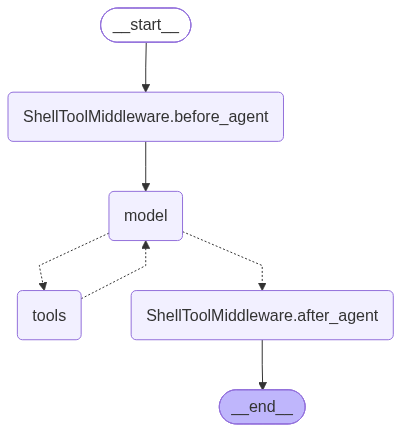

In [11]:
cinebot_shell_agent

In [12]:
from rich import print

In [13]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Create a reports folder if the same doesn't exist.")]})

In [14]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Do a Research on NBA and save it in a file nba_research.txt.")]})

In [15]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Do a Research on NBA and save it in a file nba_research.txt.',
            additional_kwargs={},
            response_metadata={},
            id='3e4bcbc0-f7af-4fdf-98d9-103af1eeadb9'
        ),
        AIMessage(
            content=[
                {
                    'id': 'toolu_01Gg6UqaT7ExHj2gnasVshdZ',
                    'caller': {'type': 'direct'},
                    'input': {
                        'command': 'cat << \'EOF\' > 
nba_research.txt\n=============================================================\n             COMPREHENSIVE 
RESEARCH ON THE NBA\n=============================================================\n\n1. OVERVIEW\n-----------\nThe
National Basketball Association (NBA) is a professional\nbasketball league in North America, widely regarded as 
the\npremier men\'s professional basketball league in the world.\nIt was founded on June 6, 1946, as the Basketball
Association\nof America (BAA) and took its current name after merging with\nthe National Basketball League (NBL) in
1949.\n\nHeadquarters : New York City, New York, USA\nCommissioner : Adam Silver (since 2014)\nWebsite      : 
www.nba.com\n\n--------------------------------------------------------------\n\n2. STRUCTURE & 
TEAMS\n---------------------\nThe NBA consists of 30 teams divided into two conferences:\n\nEASTERN CONFERENCE (15 
Teams)\n  Atlantic Division:\n    - Boston Celtics\n    - Brooklyn Nets\n    - New York Knicks\n    - Philadelphia 
76ers\n    - Toronto Raptors\n\n  Central Division:\n    - Chicago Bulls\n    - Cleveland Cavaliers\n    - Detroit 
Pistons\n    - Indiana Pacers\n    - Milwaukee Bucks\n\n  Southeast Division:\n    - Atlanta Hawks\n    - Charlotte
Hornets\n    - Miami Heat\n    - Orlando Magic\n    - Washington Wizards\n\nWESTERN CONFERENCE (15 Teams)\n  
Northwest Division:\n    - Denver Nuggets\n    - Minnesota Timberwolves\n    - Oklahoma City Thunder\n    - 
Portland Trail Blazers\n    - Utah Jazz\n\n  Pacific Division:\n    - Golden State Warriors\n    - Los Angeles 
Clippers\n    - Los Angeles Lakers\n    - Phoenix Suns\n    - Sacramento Kings\n\n  Southwest Division:\n    - 
Dallas Mavericks\n    - Houston Rockets\n    - Memphis Grizzlies\n    - New Orleans Pelicans\n    - San Antonio 
Spurs\n\n--------------------------------------------------------------\n\n3. SEASON FORMAT\n----------------\n- 
Regular Season  : October – April (~82 games per team)\n- Play-In Tournament: Top 7–10 seeds in each conference\n  
compete for the final playoff spots.\n- Playoffs        : April – June (16 teams, best-of-7 series)\n- NBA Finals  
: Best-of-7 series between Eastern &\n                    Western Conference 
Champions.\n\n--------------------------------------------------------------\n\n4. HISTORICAL 
MILESTONES\n-------------------------\n- 1946 : BAA founded; first game played.\n- 1949 : BAA merges with NBL to 
form the NBA.\n- 1954 : 24-second shot clock introduced, revolutionizing play.\n- 1967 : ABA (rival league) 
founded; led to NBA expansion.\n- 1976 : ABA–NBA merger; 4 ABA teams join the NBA.\n- 1979 : Three-point line 
introduced.\n- 1984 : David Stern becomes Commissioner; global expansion begins.\n- 1992 : "Dream Team" (USA 
Olympic team) showcases NBA stars globally.\n- 1996 : WNBA founded as the women\'s professional counterpart.\n- 
2014 : Adam Silver becomes Commissioner.\n- 2020 : NBA "Bubble" season held in Orlando during COVID-19 pandemic.\n-
2023 : Boston Celtics win the NBA Championship (2023–24 
season).\n\n--------------------------------------------------------------\n\n5. ALL-TIME RECORDS & 
STATISTICS\n----------------------------------\nMOST NBA CHAMPIONSHIPS (Franchise):\n  1. Boston Celtics       – 17
titles\n  2. Los Angeles Lakers   – 17 titles\n  3. Golden State Warriors – 7 titles\n  4. Chicago Bulls        – 6
titles\n  5. San Antonio Spurs    – 5 titles\n\nALL-TIME LEADING SCORERS:\n  1. LeBron James         – 40,0

In [16]:
result['messages'][-1].content

"The research has been successfully saved to **`nba_research.txt`**! 🏀\n\nHere's a summary of what's covered in the file:\n\n---\n\n### 📄 `nba_research.txt` — Contents Overview\n\n| # | Section | Details |\n|---|---------|---------|\n| 1 | **Overview** | NBA's founding, headquarters, and commissioner |\n| 2 | **Structure & Teams** | All 30 teams across 2 conferences and 6 divisions |\n| 3 | **Season Format** | Regular season, Play-In, Playoffs, and NBA Finals |\n| 4 | **Historical Milestones** | Key events from 1946 to 2024 |\n| 5 | **All-Time Records** | Top scorers, rebounders, assist leaders & most championships |\n| 6 | **Legendary Players** | MJ, LeBron, Kareem, Kobe, Bird, Magic, and more |\n| 7 | **NBA Awards** | MVP, Finals MVP, DPOY, ROY, and all other major awards |\n| 8 | **Global Impact & Business** | Revenue ($10B+), TV deals, G League, and international reach |\n| 9 | **Notable Rivalries** | Celtics vs. Lakers, Warriors vs. Cavs, and more |\n| 10 | **NBA Today (2024–2025)

In [17]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Create a python file Hello_world.py which has a single line print('hello Mayank').")]})

In [18]:
print(result)

{
    'messages': [
        HumanMessage(
            content="Create a python file Hello_world.py which has a single line print('hello Mayank').",
            additional_kwargs={},
            response_metadata={},
            id='287f80f0-a244-40af-a817-50a06a4baf48'
        ),
        AIMessage(
            content=[
                {
                    'id': 'toolu_019V3cRs3JNGD6GGC4xxLfog',
                    'caller': {'type': 'direct'},
                    'input': {'command': 'echo "print(\'hello Mayank\')" > Hello_world.py'},
                    'name': 'shell',
                    'type': 'tool_use',
                    'toolset_name': None
                }
            ],
            additional_kwargs={},
            response_metadata={
                'id': 'msg_011CeMEvnUBTBeubfiJseXge',
                'container': None,
                'model': 'claude-sonnet-4-6',
                'stop_details': None,
                'stop_reason': 'tool_use',
                'stop_sequence': None,
                'usage': {
                    'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0},
                    'cache_creation_input_tokens': 0,
                    'cache_read_input_tokens': 0,
                    'inference_geo': 'global',
                    'input_tokens': 732,
                    'output_tokens': 67,
                    'output_tokens_details': None,
                    'server_tool_use': None,
                    'service_tier': 'standard'
                },
                'model_name': 'claude-sonnet-4-6',
                'model_provider': 'anthropic'
            },
            id='lc_run--01a032d6-bb67-7162-9b84-5bdec4d27afd-0',
            tool_calls=[
                {
                    'name': 'shell',
                    'args': {'command': 'echo "print(\'hello Mayank\')" > Hello_world.py'},
                    'id': 'toolu_019V3cRs3JNGD6GGC4xxLfog',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 732,
                'output_tokens': 67,
                'total_tokens': 799,
                'input_token_details': {
                    'cache_read': 0,
                    'cache_creation': 0,
                    'ephemeral_5m_input_tokens': 0,
                    'ephemeral_1h_input_tokens': 0
                }
            }
        ),
        ToolMessage(
            content='<no output>',
            name='shell',
            id='6ccbf73f-39f0-4850-95b8-566ba670952a',
            tool_call_id='toolu_019V3cRs3JNGD6GGC4xxLfog',
            artifact={
                'timed_out': False,
                'exit_code': 0,
                'truncated_by_lines': False,
                'truncated_by_bytes': False,
                'total_lines': 0,
                'total_bytes': 0,
                'redaction_matches': {}
            }
        ),
        AIMessage(
            content=[
                {'text': "Let's verify the file was created correctly:", 'type': 'text'},
                {
                    'id': 'toolu_012FuR4G3fkYExjgk4XwHHoe',
                    'caller': {'type': 'direct'},
                    'input': {'command': 'cat Hello_world.py'},
                    'name': 'shell',
                    'type': 'tool_use',
                    'toolset_name': None
                }
            ],
            additional_kwargs={},
            response_metadata={
                'id': 'msg_011CeMEvwqVjqu1AhEChbCUF',
                'container': None,
                'model': 'claude-sonnet-4-6',
                'stop_details': None,
                'stop_reason': 'tool_use',
                'stop_sequence': None,
                'usage': {
                    'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0},
                    'cache_creation_input_tokens': 0,
                    'cache_read_input_tokens': 

In [19]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Create a python script which creates 2 folders with langchain_1 and langchain_2, just create the script.")]})

In [20]:
result = cinebot_shell_agent.invoke({"messages": [("user", "run the create_folders.py.")]})

In [21]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Delete the create_folders.py.")]})

In [22]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Create a file which runs a small calculator app. simple one which can run on colab.")]})

In [23]:
result = cinebot_shell_agent.invoke({"messages": [("user", "run the calculator.py.")]})

KeyboardInterrupt: 

In [24]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Delete all files and folders inside your workspace.")]})

# Custom Middleware

In [10]:
# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

`HumanInTheLoopMiddleware` handles approval for any tool. `PIIMiddleware` handles any of five PII
types. CineBot's actual business, though, has rules nothing built-in could know in advance: "no
customer books more than 2 movies in one session," "flag it if the bot ever mentions a rival
cinema chain by name," "log every cancellation in our own specific audit format." Nothing generic
can anticipate rules that are yours alone.

In [12]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."

@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

cinebot_tools = [check_showtimes, book_seats, cancel_booking, get_refund_policy]

# Callbaks, Hooks, Middleware

Hooks are extension points in custom middleware that let you intercept, inspect, or modify agent execution at specific stages of the lifecycle.


In [15]:
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"[LOG] About to call model with {len(state['messages'])} messages so far")
    return None  # None means "observed, nothing to change"


In [16]:
@before_agent
def connecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have connected to DB")
    return None  # None means "observed, nothing to change"


In [17]:
@after_agent
def disconnecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have disconnected to DB")
    return None  # None means "observed, nothing to change"


In [41]:
# @before_agent
# def log_before_model():
#     print(type(state),type(runtime))
#     """Log every call about to be made to the model."""
#     # print(f"[LOG] About to call model with {len(state['messages'])} messages so far")
#     print(f"[LOG] Hello World")

#     return None  # None means "observed, nothing to change"


In [18]:
logged_agent = create_agent(model=model, tools=[], middleware=[log_before_model, connecting_to_DB, disconnecting_to_DB])


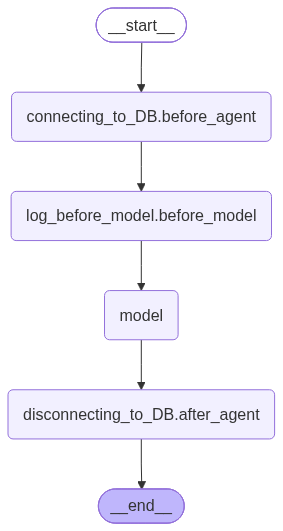

In [19]:
logged_agent

In [20]:
result = logged_agent.invoke({"messages": [("user", "Hi, How are you?")]})

I have connected to DB
[LOG] About to call model with 1 messages so far
I have disconnected to DB


In [21]:
result = logged_agent.invoke({"messages": [("user", "Great")]})

I have connected to DB
[LOG] About to call model with 1 messages so far
I have disconnected to DB


In [22]:
print(result)

{'messages': [HumanMessage(content='Great', additional_kwargs={}, response_metadata={}, id='43797e70-da55-431c-b2b4-848023a8876d'), AIMessage(content='Thank you! 😊 Is there something I can help you with today? Feel free to ask anything!', additional_kwargs={}, response_metadata={'id': 'msg_011CeMeKMbnH7Cx3skijTdUr', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 8, 'output_tokens': 26, 'output_tokens_details': None, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--01a033ef-8b6b-7662-b97a-20435b9f28b4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 26, 'total_tokens': 34, 'input_token_deta

In [49]:
# logged_agent = create_agent(model=model, tools=[get_booking,cancel_booking], middleware=[log_before_model])


In [23]:
@tool
def book_vip_lounge(movie_title: str) -> str:
    """Book a VIP lounge seat with premium service. VIP members only."""
    return f"VIP lounge seat booked for {movie_title}."



In [24]:

@wrap_model_call
def gate_vip_tools(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """Only expose book_vip_lounge to VIP members."""
    is_vip = request.state.get("is_vip_member", False)
    if not is_vip:
        allowed = [t for t in request.tools if t.name != "book_vip_lounge"]
        request = request.override(tools=allowed)
    return handler(request)


In [26]:

gated_agent = create_agent(model="anthropic:claude-haiku-4-5-20251001", tools=[*cinebot_tools, book_vip_lounge], middleware=[gate_vip_tools])
result = gated_agent.invoke({"messages": [("user", "Book me a VIP lounge seat for Dune")]})
print(result["messages"][-1].content)

I'd like to help you book a VIP lounge seat for Dune, but I need a bit more information:

**How many seats would you like to book?** 

Please note that the booking system I have access to can book seats, but I want to make sure I understand if you need:
- 1 seat (just for yourself)
- Multiple seats (for you and others)

Once you let me know the number of seats, I can proceed with the booking for Dune.


In [27]:
advanced_model = init_chat_model("anthropic:claude-sonnet-4-6")
basic_model = init_chat_model("anthropic:claude-haiku-4-5-20251001")

In [28]:
@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """Use a cheap model for short conversations, a capable one once it gets complex."""
    message_count = len(request.state["messages"])
    chosen_model = advanced_model if message_count > 10 else basic_model
    return handler(request.override(model=chosen_model))

In [29]:
cost_aware_agent = create_agent(model=basic_model, tools=cinebot_tools, middleware=[dynamic_model_selection])
result = cost_aware_agent.invoke({"messages": [("user", "Quick one -- what's showing tonight?")]})

# Class Based Middleware

In [31]:
class CallCounterMiddleware(AgentMiddleware):

  def __init__(self,warn_after: int =3):
    self._num_calls = 0
    self.warn_after = warn_after

  def before_model(self,state,runtime):
    self._num_calls+=1
    if(self._num_calls > self.warn_after):
      print("Bhai kaafi calls ho rhi hain. keep Credit card ready.")
    return None

  def after_model():
    pass

  def before_agent():
    pass

  def after_agent():
    pass

# Middleware Execution Order

In [32]:
logged_agent = create_agent(model=model, tools=[], middleware=[log_before_model,connecting_to_DB,disconnecting_to_DB])


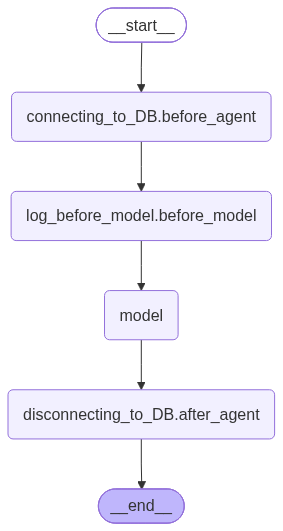

In [33]:
logged_agent

In [34]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware

agent = create_agent(
    model=init_chat_model("anthropic:claude-sonnet-4-6"),
    tools=[],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)

In [35]:
agent

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 400.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`